In [1]:
# Richardson-Lucy deconvolution for 3D microscopy stack
import numpy as np
import nrrd
from skimage.restoration import richardson_lucy

image_path = "/nfs/data28/chuyu/data/20260109_095628/reference_stack_epi.nrrd"
psf_path = "/nfs/data26/chuyu/data/20250505_181137/20250505_181137_avg_bead_volume.nrrd"

# load image and PSF
image, image_header = nrrd.read(image_path)
# exchange x and z axis
image = np.transpose(image, (2, 1, 0))
psf, psf_header = nrrd.read(psf_path)
psf = psf[::2, :, :]


In [2]:
psf.shape

(31, 21, 21)

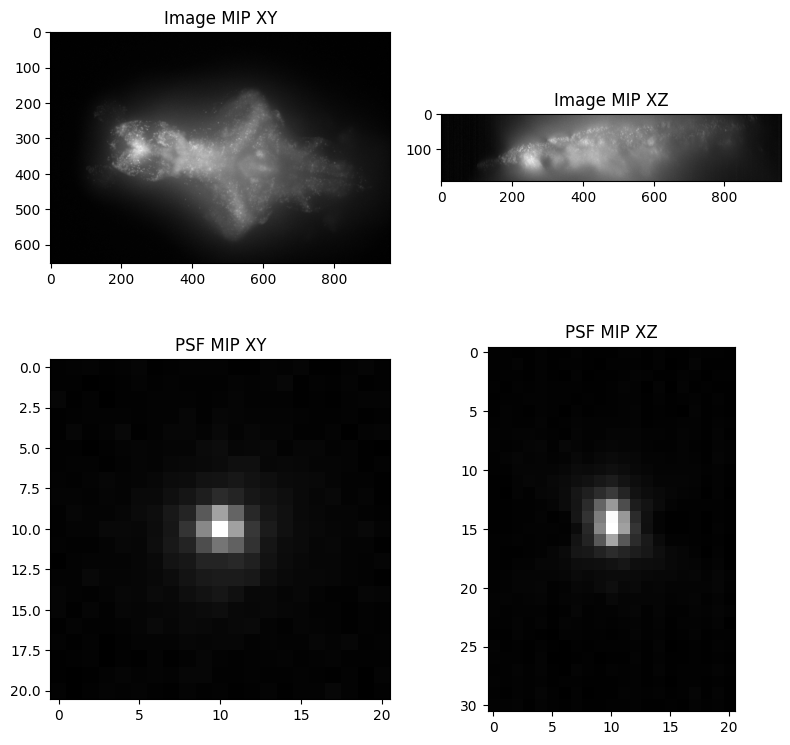

In [3]:
# plot the image and PSF as maximum intensity projections
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes[0, 0].imshow(np.max(image, axis=0), cmap='gray')
axes[0, 0].set_title('Image MIP XY')
axes[0, 1].imshow(np.max(image, axis=1), cmap='gray')
axes[0, 1].set_title('Image MIP XZ')
axes[1, 0].imshow(np.max(psf, axis=0), cmap='gray')
axes[1, 0].set_title('PSF MIP XY')
axes[1, 1].imshow(np.max(psf, axis=1), cmap='gray')
axes[1, 1].set_title('PSF MIP XZ')
plt.tight_layout()
plt.show()

In [4]:

# # convert to float and normalize PSF
# image = image.astype(np.float32)
# psf = psf.astype(np.float32)
# psf_sum = np.sum(psf)
# if psf_sum <= 0:
#     raise ValueError("PSF sum must be positive")
# psf = psf / psf_sum

# # optional: scale image to avoid numerical issues
# image = np.clip(image, 0, None)
# orig_max = image.max()
# if orig_max > 0:
#     image = image / orig_max

# # run Richardson-Lucy for multiple iteration counts and save each result
# iteration_list = [5, 10, 20, 30, 50]
# output_prefix = "/nfs/data28/chuyu/data/20260109_095628/reference_stack_epi_RL_deconv_iter"

# for n_iterations in iteration_list:
#     deconvolved = richardson_lucy(image, psf, num_iter=n_iterations, clip=False)
#     # rescale back to original intensity range
#     if orig_max > 0:
#         deconvolved = deconvolved * orig_max
#     # switch dimension before saving
#     deconvolved = np.transpose(deconvolved, (2, 1, 0))
#     out_path = f"{output_prefix}{n_iterations}.nrrd"
#     nrrd.write(out_path, deconvolved.astype(np.float32))
#     print("Saved:", out_path)

In [5]:
# # Richardson-Lucy deconvolution from scratch (FFT-based)
# import numpy as np
# import nrrd

# def _pad_psf_to_image(psf, image_shape):
#     psf_padded = np.zeros(image_shape, dtype=np.float32)
#     psf_shape = np.array(psf.shape)
#     img_shape = np.array(image_shape)
#     # center PSF in the padded array
#     start = (img_shape - psf_shape) // 2
#     end = start + psf_shape
#     slices = tuple(slice(s, e) for s, e in zip(start, end))
#     psf_padded[slices] = psf
#     # shift so that center is at the origin for FFT convolution
#     psf_padded = np.fft.ifftshift(psf_padded)
#     return psf_padded

# def _fft_convolve(image, psf_padded_fft):
#     return np.fft.ifftn(np.fft.fftn(image) * psf_padded_fft).real

# def richardson_lucy_fft(image, psf, num_iter=30, eps=1e-7):
#     # assumes image and psf are float32 and psf is normalized
#     psf_padded = _pad_psf_to_image(psf, image.shape)
#     psf_fft = np.fft.fftn(psf_padded)
#     # flipped PSF for the correction step
#     psf_mirror = psf[::-1, ::-1, ::-1]
#     psf_mirror_padded = _pad_psf_to_image(psf_mirror, image.shape)
#     psf_mirror_fft = np.fft.fftn(psf_mirror_padded)

#     estimate = np.full_like(image, np.maximum(image.mean(), eps))
#     for _ in range(int(num_iter)):
#         conv = _fft_convolve(estimate, psf_fft)
#         relative_blur = image / (conv + eps)
#         estimate *= _fft_convolve(relative_blur, psf_mirror_fft)
#     return estimate

In [6]:


# # run RL from scratch for multiple iteration counts and save each result
# iteration_list = [5, 10, 20, 30, 50]
# output_prefix_scratch = "/nfs/data28/chuyu/data/20260109_095628/reference_stack_epi_RL_deconv_scratch_iter"

# for n_iterations in iteration_list:
#     deconvolved_scratch = richardson_lucy_fft(image, psf, num_iter=n_iterations, eps=1e-7)
#     # rescale back to original intensity range
#     if orig_max > 0:
#         deconvolved_scratch = deconvolved_scratch * orig_max
#     out_path = f"{output_prefix_scratch}{n_iterations}.nrrd"
#     deconvolved_scratch = np.transpose(deconvolved_scratch, (2, 1, 0))
#     nrrd.write(out_path, deconvolved_scratch.astype(np.float32))
#     print("Saved:", out_path)

In [7]:
# # Richardson-Lucy with reflect padding to reduce boundary artefacts
# import numpy as np
# import nrrd

# def richardson_lucy_fft_padded(image, psf, num_iter=30, eps=1e-7):
#     # pad image with reflect boundary before FFT to avoid circular wrap-around artefacts
#     pad = np.array(psf.shape) // 2
#     image_padded = np.pad(image, [(p, p) for p in pad], mode='reflect')

#     psf_padded = _pad_psf_to_image(psf, image_padded.shape)
#     psf_fft = np.fft.fftn(psf_padded)
#     psf_mirror = psf[::-1, ::-1, ::-1]
#     psf_mirror_padded = _pad_psf_to_image(psf_mirror, image_padded.shape)
#     psf_mirror_fft = np.fft.fftn(psf_mirror_padded)

#     estimate = np.full_like(image_padded, np.maximum(image_padded.mean(), eps))
#     for _ in range(int(num_iter)):
#         conv = _fft_convolve(estimate, psf_fft)
#         relative_blur = image_padded / (conv + eps)
#         estimate *= _fft_convolve(relative_blur, psf_mirror_fft)

#     # crop back to original size
#     crop = tuple(slice(p, p + s) for p, s in zip(pad, image.shape))
#     return estimate[crop]

# # run padded RL for multiple iteration counts and save each result
# iteration_list = [5, 10, 20, 30, 50]
# output_prefix_padded = "/nfs/data28/chuyu/data/20260109_095628/reference_stack_epi_RL_deconv_padded_iter"

# for n_iterations in iteration_list:
#     deconvolved_padded = richardson_lucy_fft_padded(image, psf, num_iter=n_iterations, eps=1e-7)
#     if orig_max > 0:
#         deconvolved_padded = deconvolved_padded * orig_max
#     out_path = f"{output_prefix_padded}{n_iterations}.nrrd"
#     nrrd.write(out_path, np.transpose(deconvolved_padded, (2, 1, 0)).astype(np.float32))
#     print("Saved:", out_path)


In [ ]:
# Quality metrics: compare unpadded vs padded RL across iterations
# Metrics (no ground truth needed):
#   1. Sharpness     - mean gradient magnitude (higher = sharper)
#   2. Re-blur MSE   - MSE between PSF*deconvolved and original (lower = better consistency)
#   3. Border ratio  - mean intensity in border strip / mean intensity in center (lower = fewer boundary artefacts)
import numpy as np
import nrrd
import matplotlib.pyplot as plt
from scipy.ndimage import convolve

def sharpness(vol):
    """Mean gradient magnitude across all axes."""
    grads = np.gradient(vol.astype(np.float32))
    return np.mean(np.sqrt(sum(g**2 for g in grads)))

def reblur_mse(vol, psf, original):
    """Convolve deconvolved result with PSF and compare to original."""
    reblurred = convolve(vol.astype(np.float32), psf.astype(np.float32), mode='reflect')
    return np.mean((reblurred - original.astype(np.float32))**2)

def border_ratio(vol, border=10):
    """Ratio of mean border intensity to mean interior intensity."""
    interior = vol[border:-border, border:-border, border:-border]
    mask = np.ones(vol.shape, dtype=bool)
    mask[border:-border, border:-border, border:-border] = False
    return vol[mask].mean() / (interior.mean() + 1e-8)

iteration_list = [5, 10, 20, 30, 50]

metrics = {
    'unpadded': {'sharpness': [], 'reblur_mse': [], 'border_ratio': []},
    'padded':   {'sharpness': [], 'reblur_mse': [], 'border_ratio': []},
}

# image is normalized (0-1), use that for consistency
for n_iter in iteration_list:
    for label, prefix in [('unpadded', "/nfs/data28/chuyu/data/20260109_095628/reference_stack_epi_RL_deconv_scratch_iter"),
                           ('padded',   "/nfs/data28/chuyu/data/20260109_095628/reference_stack_epi_RL_deconv_padded_iter")]:
        vol_nrrd, _ = nrrd.read(f"{prefix}{n_iter}.nrrd")
        # transpose back to processing orientation (z,y,x) -> (x,y,z) used during RL
        vol = np.transpose(vol_nrrd, (2, 1, 0)).astype(np.float32)
        # if orig_max > 0:
        #     vol = vol / orig_max  # normalize to same scale as image

        metrics[label]['sharpness'].append(sharpness(vol))
        metrics[label]['reblur_mse'].append(reblur_mse(vol, psf, image))
        metrics[label]['border_ratio'].append(border_ratio(vol))

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ['Sharpness (higher=better)', 'Re-blur MSE (lower=better)', 'Border ratio (lower=better)']
keys   = ['sharpness', 'reblur_mse', 'border_ratio']

for ax, title, key in zip(axes, titles, keys):
    ax.plot(iteration_list, metrics['unpadded'][key], 'o-', label='unpadded')
    ax.plot(iteration_list, metrics['padded'][key],   's-', label='padded')
    ax.set_title(title)
    ax.set_xlabel('Iterations')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

# Print summary table
print(f"{'Iter':>6} | {'Unpad sharp':>12} {'Pad sharp':>12} | {'Unpad MSE':>12} {'Pad MSE':>12} | {'Unpad border':>13} {'Pad border':>13}")
print("-" * 90)
for i, n in enumerate(iteration_list):
    print(f"{n:>6} | {metrics['unpadded']['sharpness'][i]:>12.5f} {metrics['padded']['sharpness'][i]:>12.5f} | "
          f"{metrics['unpadded']['reblur_mse'][i]:>12.6f} {metrics['padded']['reblur_mse'][i]:>12.6f} | "
          f"{metrics['unpadded']['border_ratio'][i]:>13.5f} {metrics['padded']['border_ratio'][i]:>13.5f}")


In [ ]:
# Quality metrics: compare unpadded vs padded RL across iterations
# Metrics (no ground truth needed):
#   1. Sharpness     - mean gradient magnitude (higher = sharper)
#   2. Re-blur MSE   - MSE between PSF*deconvolved and original (lower = better consistency)
#   3. Border ratio  - mean intensity in border strip / mean intensity in center (lower = fewer boundary artefacts)
import numpy as np
import nrrd
import matplotlib.pyplot as plt
from scipy.ndimage import convolve

def sharpness(vol):
    """Mean gradient magnitude across all axes."""
    grads = np.gradient(vol.astype(np.float32))
    return np.mean(np.sqrt(sum(g**2 for g in grads)))

def reblur_mse(vol, psf, original):
    """Convolve deconvolved result with PSF and compare to original."""
    reblurred = convolve(vol.astype(np.float32), psf.astype(np.float32), mode='reflect')
    return np.mean((reblurred - original.astype(np.float32))**2)

def border_ratio(vol, border=10):
    """Ratio of mean border intensity to mean interior intensity."""
    interior = vol[border:-border, border:-border, border:-border]
    mask = np.ones(vol.shape, dtype=bool)
    mask[border:-border, border:-border, border:-border] = False
    return vol[mask].mean() / (interior.mean() + 1e-8)

iteration_list = [5, 10, 20, 30, 50]

metrics = {
    'unpadded': {'sharpness': [], 'reblur_mse': [], 'border_ratio': []},
    'padded':   {'sharpness': [], 'reblur_mse': [], 'border_ratio': []},
}

# image is normalized (0-1), use that for consistency
for n_iter in iteration_list:
    for label, prefix in [('unpadded', "/nfs/data28/chuyu/data/20260109_095628/reference_stack_epi_RL_deconv_scratch_iter"),
                           ('padded',   "/nfs/data28/chuyu/data/20260109_095628/reference_stack_epi_RL_deconv_padded_iter")]:
        vol_nrrd, _ = nrrd.read(f"{prefix}{n_iter}.nrrd")
        # transpose back to processing orientation (z,y,x) -> (x,y,z) used during RL
        vol = np.transpose(vol_nrrd, (2, 1, 0)).astype(np.float32)
        # if orig_max > 0:
        #     vol = vol / orig_max  # normalize to same scale as image

        metrics[label]['sharpness'].append(sharpness(vol))
        metrics[label]['reblur_mse'].append(reblur_mse(vol, psf, image))
        metrics[label]['border_ratio'].append(border_ratio(vol))

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ['Sharpness (higher=better)', 'Re-blur MSE (lower=better)', 'Border ratio (lower=better)']
keys   = ['sharpness', 'reblur_mse', 'border_ratio']

for ax, title, key in zip(axes, titles, keys):
    ax.plot(iteration_list, metrics['unpadded'][key], 'o-', label='unpadded')
    ax.plot(iteration_list, metrics['padded'][key],   's-', label='padded')
    ax.set_title(title)
    ax.set_xlabel('Iterations')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

# Print summary table
print(f"{'Iter':>6} | {'Unpad sharp':>12} {'Pad sharp':>12} | {'Unpad MSE':>12} {'Pad MSE':>12} | {'Unpad border':>13} {'Pad border':>13}")
print("-" * 90)
for i, n in enumerate(iteration_list):
    print(f"{n:>6} | {metrics['unpadded']['sharpness'][i]:>12.5f} {metrics['padded']['sharpness'][i]:>12.5f} | "
          f"{metrics['unpadded']['reblur_mse'][i]:>12.6f} {metrics['padded']['reblur_mse'][i]:>12.6f} | "
          f"{metrics['unpadded']['border_ratio'][i]:>13.5f} {metrics['padded']['border_ratio'][i]:>13.5f}")


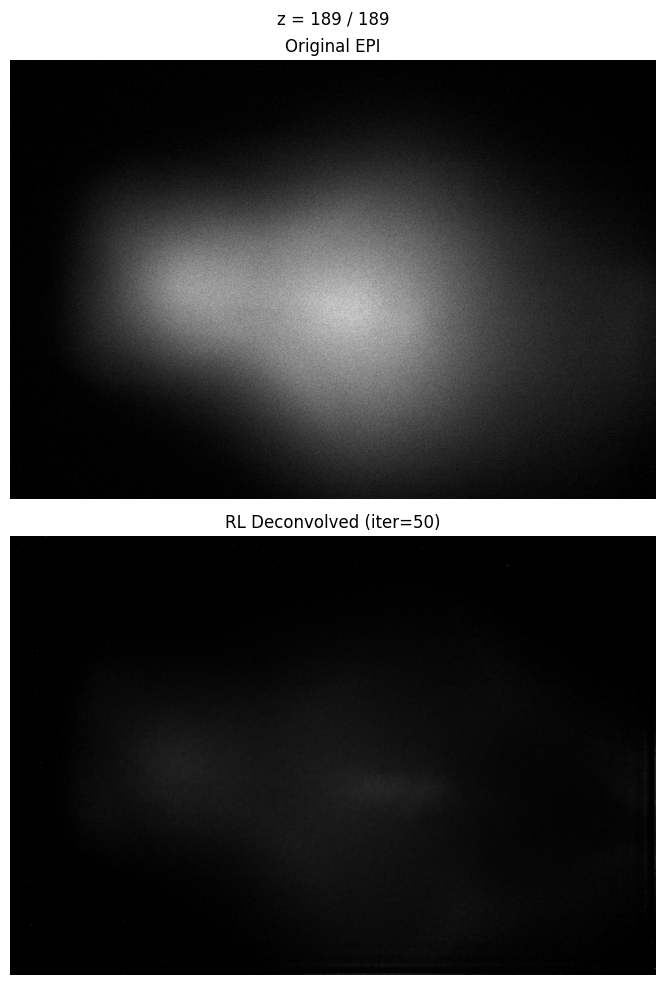

In [5]:
# Display comparison: original EPI stack vs selected RL deconvolved result
# scrolls through z-slices (axis 2) with clear_output
import matplotlib.pyplot as plt
from IPython.display import clear_output
from time import sleep
import nrrd
import numpy as np

# --- Select which result to compare ---
selected_iter = 50  # choose from: 5, 10, 20, 30, 50
frame_delay = 0     # seconds between frames
z_step =  1         # display every Nth z-slice

result_path = f"/nfs/data28/chuyu/data/20260109_095628/reference_stack_epi_RL_deconv_padded_iter{selected_iter}.nrrd"

orig, _ = nrrd.read(image_path)
result, _ = nrrd.read(result_path)

orig = orig.astype(np.float32)
result = result.astype(np.float32)

n_slices = orig.shape[2]
orig_vmin, orig_vmax = orig.min(), orig.max() / 2
result_vmin, result_vmax = result.min(), result.max() / 2

for i in range(0, n_slices, z_step):
    fig, axes = plt.subplots(2, 1, figsize=(8, 10), dpi=100)
    axes[0].imshow(orig[:, :, i].T, cmap='gray', vmin=orig_vmin, vmax=orig_vmax)
    axes[0].set_title('Original EPI')
    axes[0].axis('off')
    axes[1].imshow(result[:, :, i].T, cmap='gray', vmin=result_vmin, vmax=result_vmax)
    axes[1].set_title(f'RL Deconvolved (iter={selected_iter})')
    axes[1].axis('off')
    fig.suptitle(f'z = {i} / {n_slices - 1}')
    plt.tight_layout()
    plt.show()
    sleep(frame_delay)
    clear_output(wait=True)
